<a href="https://colab.research.google.com/github/Rogerio-mack/IMT_CD_2026/blob/main/HandsOn_Testes_de_Hipoteses.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Testes Estatísticos: Testes de Hipótese ou de Significância

**Hipótese Estatística:** Uma hipótese estatística é geralmente uma afirmação sobre um conjunto de parâmetros de uma distribuição populacional.

<br>

* **$H_0$ (Hipótese Nula):** A hipótese nula é uma hipótese estatística a ser testada e aceita ou rejeitada em favor de uma alternativa.

* **$H_1$ (Hipótese Alternativa):** Uma hipótese alternativa é uma teoria oposta em relação à hipótese nula.

<br>

**Tipos de Erro**

* **Erro de tipo $\mathrm{I}$ (Falso Positivo):** Diz-se que o erro de tipo $\mathrm{I}$ ocorre se o teste rejeita $H_0$ quando é verdadeira.

> $\alpha = P(reject \ H_0\ |\ H_0\ is\ true)$

* **Erro de tipo $\mathrm{II}$ (Falso Negativo) :** O erro de tipo $\mathrm{II}$ ocorre se o teste aceita $H_0$ quando for falso.

> $\beta = P(Accept \ H_0\ |\ H_0\ is \ not \ true)$

<br>

**Nível de significância, $\alpha$**

Sempre que $H_0$ for verdadeiro, sua probabilidade de ser rejeitado nunca é maior que $\alpha$. O valor $\alpha$, chamado de nível de significância do teste, geralmente é definido antecipadamente, sendo os valores comumente escolhidos $\alpha = 0.1, 0.05, 0.005$.

<br>

**$p-value$**

O valor P, ou probabilidade calculada, é a probabilidade de encontrar os resultados observados, ou mais extremos, quando a hipótese nula ($H_0$) de uma questão de estudo é verdadeira - a definição de 'extremo' depende de como a hipótese está sendo testada.

Se o seu **valor P for menor que o nível de significância escolhido, então você rejeita a hipótese nula**, ou seja, aceita que sua amostra fornece evidências razoáveis para apoiar a hipótese alternativa.

$\rightarrow$ O $p-value$ podemos definir o valor-p como a menor escolha que teríamos feito para o nível de significância, de forma que rejeitaríamos H0. Por exemplo, vamos supor que o nível de significância foi fixado em $\alpha$ = 0,05. Um valor-p igual a 0,20 indica que nós teríamos rejeitado H0 se tivéssemos escolhido um nível de significância de 0,20, ao menos. Como escolhemos
$\alpha$  = 0,05, não rejeitamos H0. Isto leva a uma regra simplista, mas usual, onde rejeitamos H0 se o valor-p é menor que
$\alpha$  e não rejeitamos H0 caso contrário.



In [ ]:
def printp(p_valor, significancia=0.05):
  if p_valor < significancia:
      print("Rejeita a hipótese nula, H_0.")
  else:
      print("Não rejeita a hipótese nula, não há evidências para afirmar H_a.")

printp(0.01)

Rejeita a hipótese nula, H_0.


Mas atenção **ausência de evidência não é evidência de ausência**, o experimento, por exemplo pode ser fraco ou mal conduzido.

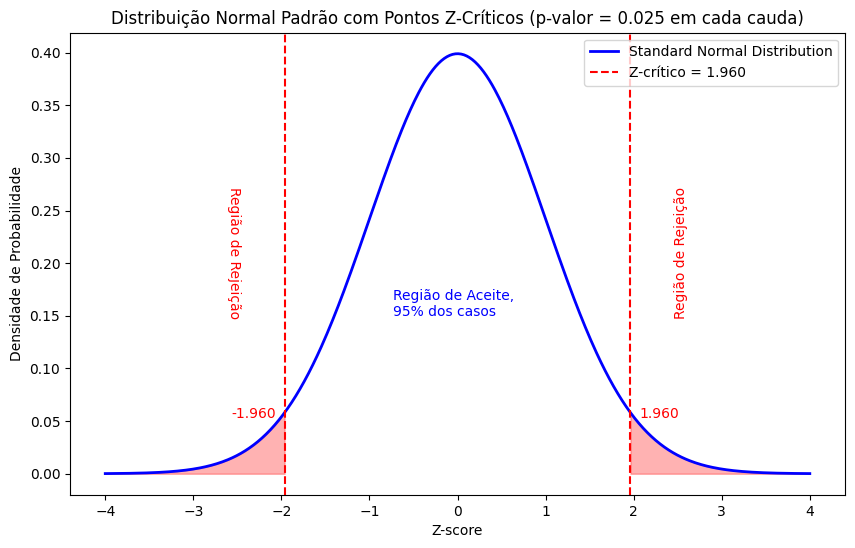

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

mu = 0
sigma = 1

x = np.linspace(mu - 4*sigma, mu + 4*sigma, 500)

pdf = norm.pdf(x, mu, sigma)

plt.figure(figsize=(10, 6))
plt.plot(x, pdf, color='blue', lw=2, label='Standard Normal Distribution')

z_critical_positive = norm.ppf(1 - 0.025)
z_critical_negative = norm.ppf(0.025)

plt.axvline(z_critical_positive, color='red', linestyle='--', lw=1.5, label=f'Z-crítico = {z_critical_positive:.3f}')
plt.axvline(z_critical_negative, color='red', linestyle='--', lw=1.5)

x_reject_positive = x[x > z_critical_positive]
x_reject_negative = x[x < z_critical_negative]
plt.fill_between(x_reject_positive, 0, norm.pdf(x_reject_positive, mu, sigma), color='red', alpha=0.3)
plt.fill_between(x_reject_negative, 0, norm.pdf(x_reject_negative, mu, sigma), color='red', alpha=0.3)

plt.text(z_critical_positive + 0.1, 0.05, f'{z_critical_positive:.3f}', color='red', verticalalignment='bottom')
plt.text(z_critical_negative - 0.1, 0.05, f'{z_critical_negative:.3f}', color='red', horizontalalignment='right', verticalalignment='bottom')
plt.text(z_critical_positive + 0.5, 0.15, 'Região de Rejeição', color='red', rotation=90)
plt.text(z_critical_negative - 0.5, 0.15, 'Região de Rejeição', color='red', rotation=270, horizontalalignment='right')

plt.text(-0.73, 0.15, 'Região de Aceite,\n95% dos casos', color='blue')

plt.title('Distribuição Normal Padrão com Pontos Z-Críticos (p-valor = 0.025 em cada cauda)')
plt.xlabel('Z-score')
plt.ylabel('Densidade de Probabilidade')
plt.legend(loc='upper right')


plt.show()

## Testes Paramétricos

Os testes paramétricos procuram inferir propriedades de populações a partir de amostras assumindo modelos probabilísticos para os dados ou para estatísticas derivadas dos dados.



### Hipóteses comuns dos testes paramétricos

| Hipótese                            | Comentário                               |
| ----------------------------------- | ---------------------------------------- |
| Independência                       | normalmente a mais importante            |
| Distribuição aproximadamente normal | especialmente para pequenas amostras     |
| Homocedasticidade                   | igualdade de variâncias em alguns testes |


### Notas

- Paramétrico, diz respeito a distribuições com parâmetros finitos, na prática em um curso introdutório isso equivale a empregarmos uma distribuição distribuição normal, embora existam outros testes paramétricos referentes a outras distruições (Poisson test para eventos raros, Weibull tests para confiabilidade, sobrevivência etc.)
- O teste z é raramente empregado, por desconhecermos a variância da população, é bastante mais comum o emprego do teste t
- O teste t de Welch é frequentemente preferível ao teste t clássico; não tem o pressuposto de variâncias iguais, e com amostras moderadas/grandes tornam muitos testes robustos devido ao TCL.

| Subseção                      | Objetivo                  |
| ----------------------------- | ------------------------- |
| 1 **Escolhendo o teste correto** | o problema?               |
| 2 z-test                    | introdução histórica      |
| 3 One-sample t-test         | média vs valor            |
| 4 Independent t-test        | comparação de grupos      |
| 5 Paired t-test             | medidas pareadas          |
| 6 Welch t-test              | variâncias diferentes     |
| 7 One-way ANOVA             | múltiplos grupos          |
| 8 Repeated Measures ANOVA   | medições repetidas        |
| 9 Post-hoc Tests            | localizar diferenças      |
| 10 Effect Size              | magnitude do efeito       |
| 11 Statistical Power        | sensibilidade estatística |


### Escolhendo o Teste

A escolha normalmente depende de:

- tipo do dado (contínuo, categórico);
- número de grupos;
- independência;
- pareamento;
- hipótese sobre médias;
- distribuição dos dados.

| Situação                          | Teste                   |
| --------------------------------- | ----------------------- |
| Média vs valor                    | One-sample t-test       |
| Dois grupos independentes         | Welch t-test            |
| Dois grupos pareados              | Paired t-test           |
| Mais de dois grupos independentes | One-way ANOVA           |
| Medidas repetidas                 | Repeated Measures ANOVA |


### z-test

$$z = \frac{\bar{x}-\mu}{\sigma/\sqrt{N}}$$

Na prática pouco empregado pois, em geral, não conhecemos a variância da população.

**Exempo**. Uma fábrica produz parafusos cujo diâmetro histórico possui:

- média nominal = 10 mm;
- desvio padrão populacional conhecido = 0.2 mm.

Deseja-se verificar se uma nova máquina alterou o diâmetro médio.

In [ ]:
import numpy as np
from statsmodels.stats.weightstats import ztest

np.random.seed(42)

# Dados simulados
x = np.random.normal(loc=10, scale=0.2, size=40)

# H0: média = 10
z_stat, p_value = ztest(x, value=10)

print("z =", z_stat)
print("p =", p_value)

z = -1.4512675749556536
p = 0.14670536656957606


### One-Sample t-test

$$t = \frac{\bar{x}-\mu}{s/\sqrt{N}}$$


**Exemplo**. Um sensor industrial deveria operar com temperatura média:

50 °C.

Deseja-se verificar se a média real difere desse valor.

* $H_0$: média = 50
* $H_1$: média $\ne$ 50

Reportar a estatística t (ou valor-t) junto com o p-value é uma prática recomendada na estatística e em publicações científicas porque o p-value informa se existe uma diferença significativa, enquanto a estatística t ajuda a entender quão forte e em que direção é essa evidência.

In [ ]:
import numpy as np
from scipy.stats import ttest_1samp

np.random.seed(42)

x = np.random.normal(loc=50, scale=2, size=20)

t_stat, p_value = ttest_1samp(x, popmean=50)
# t_stat, p_value = ttest_1samp(x, popmean=50, alternative='less') # (alternative='two-sided', 'less', 'greater').

print("t =", t_stat)    # a estatística é
print("p =", p_value)
printp(p_value)

t = -0.7979664336555974
p = 0.43475058842709724
Não rejeita a hipótese nula, não há evidências para afirmar H_a.


### Independent t-test

**Lembre-se dos pressupostos**. Teste clássico ainda assume variâncias iguais, portanto o t Welch costuma ser preferível e robusto o suficiente.

**Exemplo** Deseja-se comparar a resistência mecânica de dois tratamentos térmicos distintos.

In [ ]:
import numpy as np
from scipy.stats import ttest_ind

np.random.seed(42)

A = np.random.normal(100, 10, 30)
B = np.random.normal(108, 10, 30)

t_stat, p_value = ttest_ind(A, B, equal_var=True)

print("t =", t_stat)
print("p =", p_value)

t = -3.666994001532641
p = 0.000534400043041286


### Welch t-test

Um versão robusta do teste t que não assume variâncias iguais. Hoje é frequentemente recomendado como o padrão.

**Exemplo**. Comparar tempos de resposta de dois aplicativos com variâncias muito diferentes.

In [ ]:
import numpy as np
from scipy.stats import ttest_ind

np.random.seed(42)

A = np.random.normal(100, 5, 30)
B = np.random.normal(110, 20, 35)

t_stat, p_value = ttest_ind(A, B, equal_var=False)

print("t =", t_stat)
print("p =", p_value)

t = -2.395043727935373
p = 0.021547228044876302


Se o teste t Clássico aceita $H_0$, o t Welch também.

In [ ]:
A = np.random.normal(100, 5, 30)
B = np.random.normal(110, 20, 35)

B = np.random.normal(106, 5, 30)
t_stat, p_welch = ttest_ind(A, B, equal_var=False)
t_stat, p_tclassico = ttest_ind(A, B, equal_var=True)

p_welch > p_tclassico

np.True_

### Paired t-test

Usado quando observações são, pareadas, **dependentes**, como antes/depois, mesmo indivíduo,
mesma máquina etc.

**Exemplo**. Medições de consumo energético antes e
depois de uma otimização de software.

In [ ]:
import numpy as np
from scipy.stats import ttest_rel

np.random.seed(42)

before = np.random.normal(100, 8, 20)
after = before - np.random.normal(5, 2, 20)

t_stat, p_value = ttest_rel(before, after)

print("t =", t_stat)
print("p =", p_value)

t = 10.320726759866911
p = 3.1575040473426446e-09


#### ttest $\times$ welch $\times$ paired

1. O Welch é mais conservador (p-valor maior) para evitar falsos positivos quando o pressuposto de variâncias iguais é violado.

2. O teste t pareado é menos conservador para dados formente correlacionado (p-valor menor) para evitar falsos negativos quando o pressuposto de independência não se verifica.



### One-Way ANOVA

* $H_0$: $\mu_0 = \mu_1 =...=\mu_n$

Estamos interessados na **variabilidade dos valores**... Mas a ANOVA NÃO informa quais grupos diferem (outros testes como Tukey ou Bonferroni são em geral aplicados como *Post Hoc*).

In [ ]:
import numpy as np
from scipy.stats import f_oneway

np.random.seed(42)

A = np.random.normal(100, 10, 30)
B = np.random.normal(105, 10, 30)
group_C = np.random.normal(102, 10, 30) # Renamed C to group_C

F, p = f_oneway(A, B, group_C)

print("F =", F)
print("p =", p)

F = 2.87395351357493
p = 0.0618526563842582


In [ ]:
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
import numpy as np

if 'C' in globals() and isinstance(globals()['C'], np.ndarray):
    del globals()['C']

# Combine the data into a single DataFrame
df_anova = pd.DataFrame({
    'value': np.concatenate([A, B, group_C]), # Use group_C here
    'group': ['A']*len(A) + ['B']*len(B) + ['C']*len(group_C) # group_C here
})

# Fit a linear model (ANOVA is a special case of linear model)
model = smf.ols('value ~ C(group)', data=df_anova).fit()

# Perform ANOVA on the fitted model
anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

               sum_sq    df         F    PR(>F)
C(group)   509.838055   2.0  2.873954  0.061853
Residual  7716.880356  87.0       NaN       NaN


#### t-test $\times$ ANOVA
Semelhante ao que falamos antes, a ANOVA é mais conservadora e gera p-values maiores. t-test realizados para pares de grupos tendem a gerar mais falsos positivos.

### Repeated Measures ANOVA

Medições repetidas como mesmos indivíduos/sistemas.

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.stats.anova import AnovaRM

np.random.seed(42)

subjects = np.arange(10)

data = pd.DataFrame({
    'subject': np.repeat(subjects, 3),
    'condition': ['A', 'B', 'C'] * 10,
    'score': np.random.normal(100, 10, 30)
})

anova = AnovaRM(
    data,
    depvar='score',
    subject='subject',
    within=['condition']
)

result = anova.fit()

print(result)

                 Anova
          F Value Num DF  Den DF Pr > F
---------------------------------------
condition  2.0526 2.0000 18.0000 0.1574



#### Tukey

Para localizar as diferenças entre grupos.

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pandas as pd
import numpy as np

np.random.seed(42)

values = np.concatenate([
    np.random.normal(100,10,30),
    np.random.normal(110,10,30),
    np.random.normal(120,10,30)
])

groups = (
    ['A']*30 +
    ['B']*30 +
    ['C']*30
)

df = pd.DataFrame({
    'value': values,
    'group': groups
})

tukey = pairwise_tukeyhsd(
    endog=df['value'],
    groups=df['group']
)

print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     A      B  10.6698 0.0001  4.8714 16.4683   True
     A      C  22.0103    0.0 16.2119 27.8087   True
     B      C  11.3405    0.0  5.5421 17.1389   True
----------------------------------------------------


### Effect Size, d-Cohen

$p-values$ indicam evidência estatística, mas NÃO indicam a magnitude do efeito.

**d-Cohen**

$$d-Cohen = \frac{\mu_1 - \mu_2}{\sigma}$$

Em geral, 0.2 efeito pequeno, 0.5 médio e 0.8 grande.


In [ ]:
import numpy as np

A = np.random.normal(100, 10, 30)
B = np.random.normal(110, 10, 30)

mean_diff = np.mean(B) - np.mean(A)

pooled_std = np.sqrt(
    (
        np.std(A, ddof=1)**2 +
        np.std(B, ddof=1)**2
    ) / 2
)

d = mean_diff / pooled_std

print(d)

0.9556742631427494


### Poder estatístico

“Qual a chance do meu experimento realmente detectar o efeito que procuro?”

$$ Power = P(rejeitar H_0 |H_1 verdade) $$

Isto é existe diferença real, um novo tratamento realmente funciona, existe efeito verdadeiro? Power é 1 - $\beta$, isto é NÃO rejeitar $H_0$ quando ela é falsa (erro Tipo II).

**Importante**: Idealmente feita **antes do experimento!**.

| Power | Significado                      |
| ----- | -------------------------------- |
| 0.2   | experimento muito fraco          |
| 0.5   | detecta metade dos efeitos reais |
| 0.8   | padrão clássico                  |
| 0.95  | experimento muito sensível       |


In [ ]:
from statsmodels.stats.power import TTestIndPower

analysis = TTestIndPower()

n = analysis.solve_power(
    effect_size=0.8,
    alpha=0.05,
    power=0.8
)

print(n)

25.524571854446112


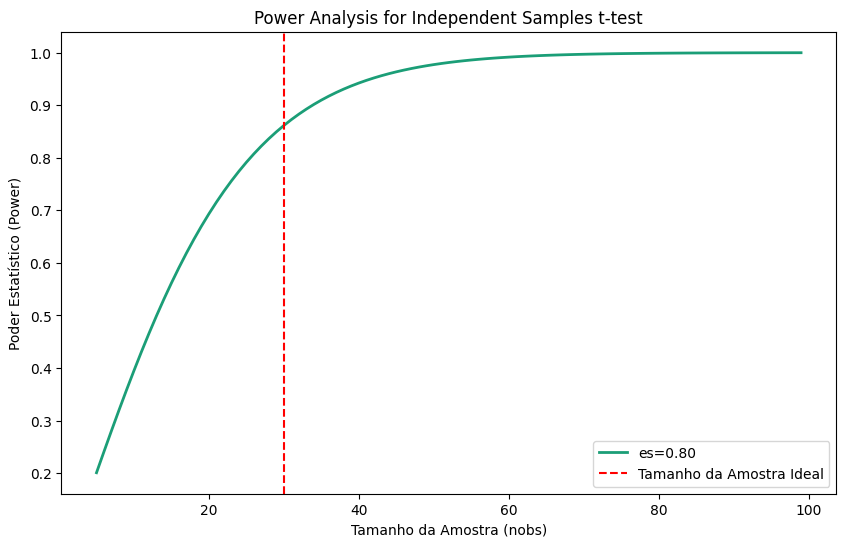

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.power import TTestIndPower

if 'analysis' not in globals() or not isinstance(analysis, TTestIndPower):
    analysis = TTestIndPower()

nobs_range = np.arange(5, 100)

fig = plt.figure(figsize=(10, 6))
analysis.plot_power(dep_var='nobs', nobs=nobs_range, effect_size=[0.8], alpha=0.05, title='Power Analysis for Independent Samples t-test', ax=fig.gca())
plt.xlabel('Tamanho da Amostra (nobs)')
plt.ylabel('Poder Estatístico (Power)')

plt.axvline(x=30, color='red', linestyle='--', label='Tamanho da Amostra Ideal')
plt.legend()
plt.show()

**Por isso é tão comum falarmos de amostras ~ 30.**

#### Calculando a *posteriori*

Pode, mas cuidado.

In [ ]:
from statsmodels.stats.power import TTestIndPower

analysis = TTestIndPower()

power = analysis.solve_power(
    effect_size=0.8,
    nobs1=30,
    alpha=0.05
)

print(power)

0.8614225160229566


Com simulação,

In [ ]:
import numpy as np
from scipy.stats import ttest_ind

np.random.seed(42)

n_sim = 1000
detections = 0

for _ in range(n_sim):

    A = np.random.normal(0, 1, 64)     # Sua simulação
    B = np.random.normal(0.5, 1, 64)

    _, p = ttest_ind(A, B)

    if p < 0.05:
        detections += 1

power = detections / n_sim

print(power)

0.796


### Sumário Testes Paramétricos

| Objetivo          | Função                                |
| ----------------- | ------------------------------------- |
| z-test            | `statsmodels.stats.weightstats.ztest` |
| one-sample t      | `scipy.stats.ttest_1samp`             |
| independent t     | `scipy.stats.ttest_ind`               |
| paired t          | `scipy.stats.ttest_rel`               |
| Welch             | `ttest_ind(equal_var=False)`          |
| ANOVA             | `scipy.stats.f_oneway`                |
| repeated measures | `statsmodels.stats.anova.AnovaRM`     |
| Tukey             | `pairwise_tukeyhsd`                   |
| effect size       | cálculo manual / `pingouin`           |
| power analysis    | `statsmodels.stats.power`             |


## Pressupostos

Antes de aplicar um teste estatístico, precisamos avaliar:

- distribuição dos dados;
- igualdade de variâncias;
- independência;
- estacionariedade (para Séries Temporais);

Ou os pressupostos (assumptions) dos testes. Esses **pressupostos não são regras absolutas, mas indicam quando certos testes são mais confiáveis.**

- muitos testes são robustos;
- pequenas violações frequentemente são aceitáveis;
- grandes amostras permite ser mais flexível.

| Subseção                                    | Objetivo              |
| ------------------------------------------- | --------------------- |
| 1 Normality Tests                         | verificar normalidade |
| 2 Equality of Variance Tests              | homocedasticidade     |
| 3 Stationarity Tests                      | séries temporais      |



Os testes não dispensam a inspeção visual que é muito importante.

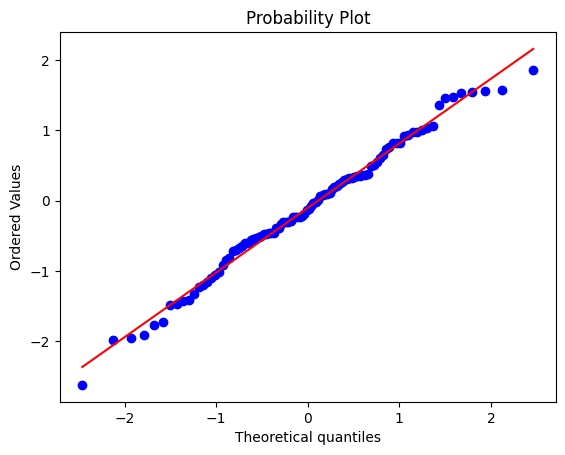

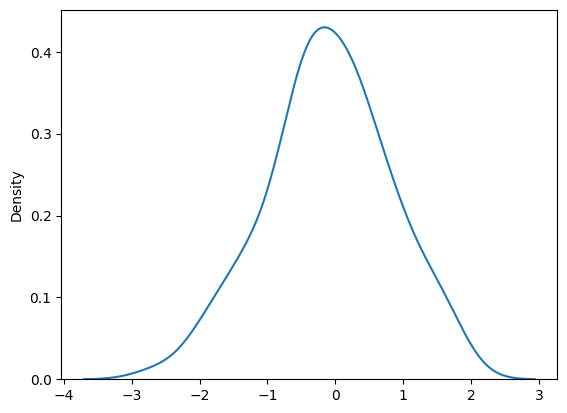

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import probplot

np.random.seed(42)

x = np.random.normal(0, 1, 100)

probplot(x, dist='norm', plot=plt)

plt.show()

sns.kdeplot(x)

plt.show()

#### Normalidade

- Shapiro, pequenas amostras
- D’Agostino K² Test, amostras moderadas e grandes `normaltest()`
- outros

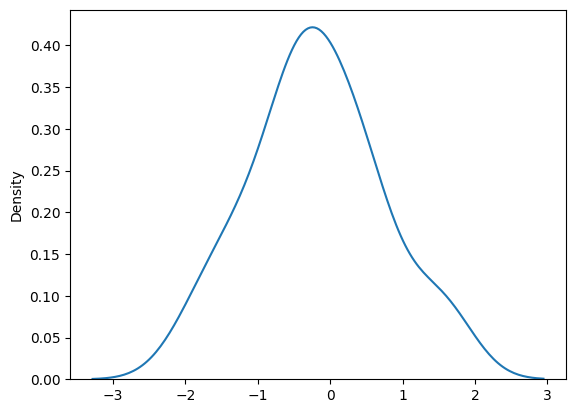

0.9751383104692292 0.686805494291708


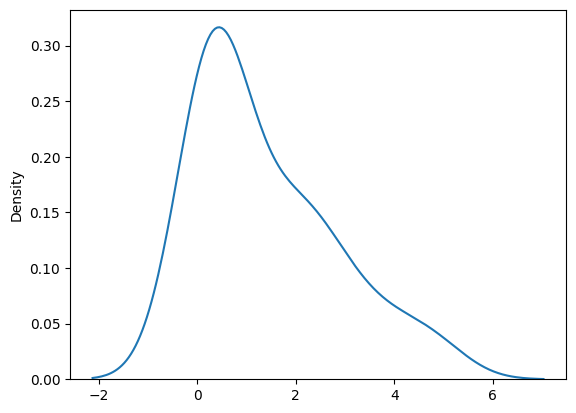

0.8551228622524285 0.0007952316256428883


In [ ]:
import numpy as np
from scipy.stats import shapiro, lognorm, weibull_max, weibull_min


np.random.seed(42)

x = np.random.normal(0, 1, 30)
sns.kdeplot(x)
plt.show()
stat, p = shapiro(x)

print(stat, p)

x = lognorm.rvs(s=2,size=30)
x = weibull_max.rvs(c=4,size=30)
x = weibull_min.rvs(c=0.8,size=30)
sns.kdeplot(x)
plt.show()
stat, p = shapiro(x)
print(stat, p)

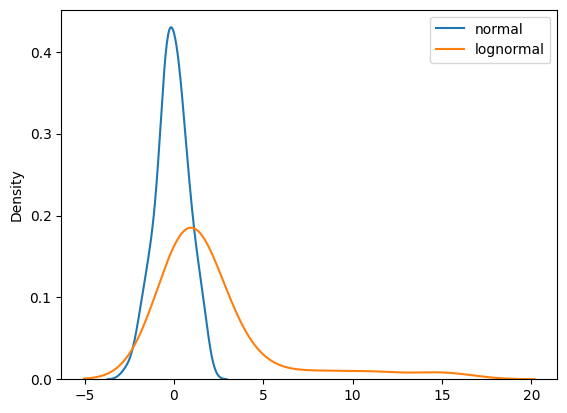

35.36432530211738 2.092831833012844e-08


In [ ]:
from scipy.stats import normaltest
import numpy as np

np.random.seed(42)

x = np.random.normal(0, 1, 100)
x1 = lognorm.rvs(s=1.1,size=30)

sns.kdeplot(x)
sns.kdeplot(x1)
plt.legend(['normal', 'lognormal'])
plt.show()
stat, p = normaltest(x1)

print(stat, p)

Importante, para testes pareados, no lugar de fazermos o teste de normalidade das duas amostras do teste, por exemplo shapiro(A) e shapiro(B), o pressuposto correto é a normalidade shapiro(A - B).

#### Variâncias iguais

- bartlett, dados normais
- levene, dados que violam a normalidade
- Fisher, dados normais

In [ ]:
from scipy.stats import bartlett
import numpy as np

np.random.seed(42)

A = np.random.normal(0,1,30)
B = np.random.normal(0,1.5,30)

stat, p = bartlett(A, B)

print(stat, p)

5.336456029701257 0.02088388814184213


In [ ]:
from scipy.stats import levene
import numpy as np

np.random.seed(42)

A = np.random.normal(0,1,30)
B = np.random.normal(0,1.5,30)

stat, p = levene(A, B)

print(stat, p)

6.499877950285229 0.013454320895372985


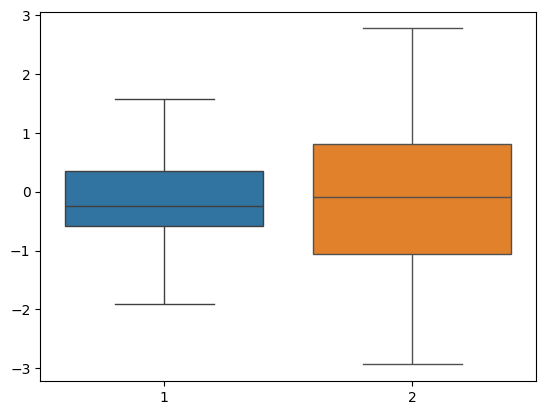

In [ ]:
sns.boxplot(x=1,y=A)
sns.boxplot(x=2,y=B)
plt.show()

In [ ]:
import numpy as np
from scipy.stats import f

np.random.seed(42)

A = np.random.normal(0,1,30)
B = np.random.normal(0,1.5,30)

F = np.var(A, ddof=1) / np.var(B, ddof=1)

df1 = len(A)-1
df2 = len(B)-1

p = 2 * min(
    f.cdf(F, df1, df2),
    1 - f.cdf(F, df1, df2)
)

print(F, p)

0.4152541679996125 0.02087559545078621


#### **Discussão: Escalas Likert**

### Sumário dos Pressupostos

| Objetivo         | Função                               |
| ---------------- | ------------------------------------ |
| QQ-plot          | `scipy.stats.probplot`               |
| Shapiro-Wilk     | `scipy.stats.shapiro`                |
| D’Agostino K²    | `scipy.stats.normaltest`             |
| Bartlett         | `scipy.stats.bartlett`               |
| Levene           | `scipy.stats.levene`                 |
| Fisher F-test    | `scipy.stats.f`                      |



## Testes não Paramétricos

São aplicados quando normalidade, homocedasticidade ou continuidade não são plausíveis nos dados.

- assimetria;
- outliers;
- distribuições arbitrárias;
- dados ordinais.

Frequentemente operam sobre "ranks", no lugar de médias e funcionam bem para escalas (Likert, por exemplo), poucas amostras, dados ordinais etc.
Mas ainda são, em geral, mantidas algumas hipóteses como:

- independência;
- estrutura amostral (aleatoriedade da amostra);
- semelhantes de distribuição.

| Teste Paramétrico          | Alternativa não paramétrica                               |
| ----------------- | ------------------------------------- |
| independent t     |  Mann-Whitney U Test            |
| paired t          | Wilcoxon Signed-Rank Test            |
| ANOVA             | Kruskal-Wallis H Test                |
| repeated measures | Friedman Test     |


### Mann-Whitney U Test

Em uma distribuição não normal, não simétrica, não faz sentido comparar médias.O Mann-Whitney U Test **Em vez de comparar médias compara ranks.** Em geral podemos entender isso com comparação da mediana: "a mediana está na mesma posição (rank) nos dois grupos"?

- $H_0$: mediana(A) $=$ mediana(B)
- $H_a$: mediana(A) $\ne$ mediana(B)

In [ ]:
import numpy as np
from scipy.stats import mannwhitneyu

np.random.seed(42)

A = np.random.exponential(scale=1, size=30)
B = np.random.exponential(scale=2, size=30)

stat, p = mannwhitneyu(A, B) # alternative{‘two-sided’, ‘less’, ‘greater’},

print(stat, p)

280.0 0.012211939665202363


#### A ideia de ranks

In [ ]:
import numpy as np
from scipy.stats import rankdata

A = [5, 7, 9]
B = [1, 3, 11]
# B = [1,8,11]

combined = np.concatenate([A, B])

ranks = rankdata(combined)

print("Valores:", combined)
print("Ranks:", ranks)

Valores: [ 5  7  9  1  3 11]
Ranks: [3. 4. 5. 1. 2. 6.]


In [ ]:
ranks_A = ranks[:len(A)]
ranks_B = ranks[len(A):]

print(ranks_A)
print(ranks_B)

print("Soma A =", np.sum(ranks_A))
print("Soma B =", np.sum(ranks_B))

[3. 4. 5.]
[1. 2. 6.]
Soma A = 12.0
Soma B = 9.0


| Valor | Grupo | Rank |
| ----- | ----- | ---- |
| 1     | B     | 1    |
| 3     | B     | 2    |
| 5     | A     | 3    |
| 7     | A     | 4    |
| 9     | A     | 5    |
| 11    | B     | 6    |


Veja que o rank dos valores de A são maiores! Mas o teste não usa o cálculo de rank diretamente, mas emprega uma estatística que conta quantas vezes valores de A > B. Algo como:

In [ ]:
A = [5,7,9]
B = [1,3,11]
# B = [1,8,11]

wins = 0

for a in A:
    for b in B:

        if a > b:
            wins += 1

print(f'Vitórias de A: {wins} de {len(A) * len(B)} combinações')

Vitórias de A: 6 de 9 combinações


Claramente aqui, P(A > B) é grande.

O Mann-Whitney não compara médias diretamente, ele avalia se um grupo tende a produzir valores maiores que o outro $P(A>B)$, qual a probabilidade de um elemento aleatório de A ser maior que um elemento aleatório de B.

### Wilcoxon Signed-Rank Test (dados pareados)

Compara o rank das diferenças para amostras pareadas. $H_0$ é que a mediana das diferenças entre as observações pareadas é igual a zero.

In [ ]:
import numpy as np
from scipy.stats import wilcoxon

np.random.seed(42)

before = np.random.normal(100,10,20)
after = before - np.random.normal(5,5,20)

stat, p = wilcoxon(before, after)

print(stat, p)

28.0 0.002712249755859375


### Kruskal-Wallis H Test

Alternativa não paramétrica à one-way ANOVA. Ranks de múltiplos grupos.

In [ ]:
import numpy as np
from scipy.stats import kruskal

np.random.seed(42)

A = np.random.exponential(1,30)
B = np.random.exponential(1.2,30)
C = np.random.exponential(10.5,30)

stat, p = kruskal(A, B, C)

print(stat, p)

37.755018315018276 6.3328899454678386e-09


### Friedman

Alternativa não paramétrica à repeated one-way ANOVA. Ranks de múltiplos grupos.

In [ ]:
import numpy as np
from scipy.stats import friedmanchisquare

np.random.seed(42)

A = np.random.normal(100,10,10)
B = np.random.normal(105,10,10)
C = np.random.normal(110,10,10)

stat, p = friedmanchisquare(A, B, C)

print(stat, p)

9.800000000000011 0.007446583070924297


### **Permutation Test**

É uma **abordagem computacional moderna**, só possível pela disponibilidade de dados e poder computacional.

A ideia central do método é a seguinte:

Em $H_0$, os rótulos dos grupos são intercambiáveis, então, podemos:   

- embaralhar labels;
- recalcular estatística;
- estimar distribuição nula empiricamente.

Isto não depende de nenhuma distribuição teórica conhecida.

In [ ]:
import numpy as np
from scipy.stats import rankdata

df = pd.DataFrame()

df['valuesA'] = [80, 85, 78, 92, 75, 82]
df['valuesB'] = [78, 81, 78, 88, 70, 80]

df['ranksA'] = rankdata(df['valuesA'])
df['ranksB'] = rankdata(df['valuesB'])

df['abs(Diferença)'] = np.abs(df['ranksB'] - df['ranksA'])

df


,valuesA,valuesB,ranksA,ranksB,abs(Diferença)
0,80,78,3.0,2.5,0.5
1,85,81,5.0,5.0,0.0
2,78,78,2.0,2.5,0.5
3,92,88,6.0,6.0,0.0
4,75,70,1.0,1.0,0.0
5,82,80,4.0,4.0,0.0


In [ ]:
import numpy as np
from scipy.stats import rankdata

df = pd.DataFrame()

df['valuesB'] = [80, 85, 78, 92, 75, 82] # Before
df['valuesA'] = [78, 81, 78, 88, 70, 80] # After

df['abs(Diferença)'] = np.abs(df['valuesA'] - df['valuesB'])

df['ranks Dif'] = rankdata(df['abs(Diferença)'])
df

,valuesB,valuesA,abs(Diferença),ranks Dif
0,80,78,2,2.5
1,85,81,4,4.5
2,78,78,0,1.0
3,92,88,4,4.5
4,75,70,5,6.0
5,82,80,2,2.5


| Par | Antes | Depois | Diferença A/D | Dif em Módulo | Posto |
|-|-|-|-|-|-|
| Par 1 | 80 | 78 | +2 | 2 | 1 |
| Par 2 | 85 | 81 | +4 | 4 | 2 |
| Par 3 | 78 | 78 | 0 | 0 | Ignorado |
| Par 4 | 92 | 88 | +4 | 4 | 2 |
| Par 5 | 75 | 70 | +5 | 5 | 4 |
| Par 6 | 82 | 80 | +2 | 2 | 1 |

**Exemplo**. $\mu_A \ne \mu_b$

In [ ]:
import numpy as np

np.random.seed(42)

A = np.random.exponential(1,30)
B = np.random.exponential(1.3,30)

diff_obs = np.mean(A) - np.mean(B) # os testes podem empregar média, mediana

combined = np.concatenate([A,B])

perm_diffs = []

for _ in range(10000):

    np.random.shuffle(combined)

    A_perm = combined[:30]
    B_perm = combined[30:]

    perm_diffs.append(
        np.mean(A_perm) - np.mean(B_perm)
    )

perm_diffs = np.array(perm_diffs)

p_value = np.mean(
    np.abs(perm_diffs) >= np.abs(diff_obs) # aqui é o módulo e, portanto estamos testando muA != muB

    # perm_diffs >= diff_obs # aqui seria para muA > muB
    # perm_diffs <= diff_obs # aqui seria para muA < muB
)

print(diff_obs)
print(p_value) # note que você constrói diretamente a região crítica e, portanto, não precisa "dividir" por 2 no teste one-side.

-0.5971860032801114
0.0499


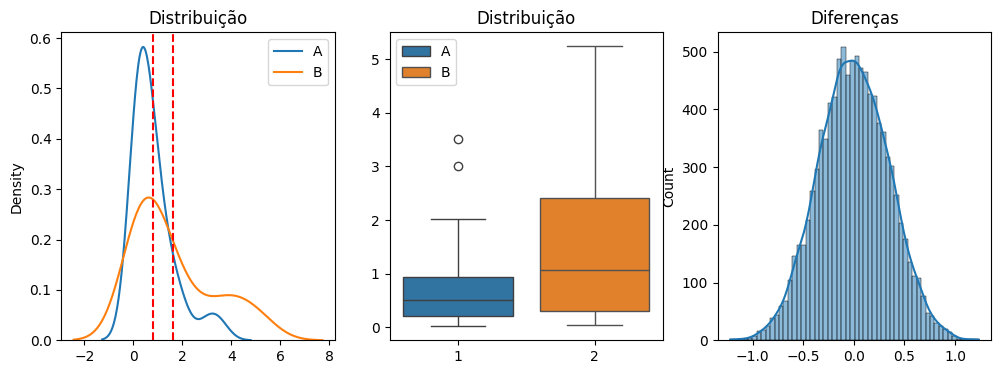

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1,3,1)
sns.kdeplot(A)
sns.kdeplot(B)
plt.axvline(x=np.mean(A), color='red', linestyle='--')
plt.axvline(x=np.mean(B), color='red', linestyle='--')
plt.legend(['A', 'B'])
plt.title('Distribuição')

plt.subplot(1,3,2)
sns.boxplot(x=1,y=A)
sns.boxplot(x=2,y=B)
plt.legend(['A', 'B'])
plt.title('Distribuição')

plt.subplot(1,3,3)
sns.histplot(perm_diffs,kde=True)
plt.title('Diferenças')


plt.show()


In [ ]:
#@markdown Usando a função `permutation_test` `scipy`

import numpy as np
from scipy.stats import permutation_test

np.random.seed(42)

A = np.random.exponential(1,30)
B = np.random.exponential(1.5,30)

def statistic(x, y):
    return np.mean(x) - np.mean(y)

result = permutation_test(
    (A, B),
    statistic,
    permutation_type='independent',
    alternative='two-sided',
    n_resamples=10000
)

print(result.statistic)
print(result.pvalue)

-0.8130300508718254
0.015198480151984802


### Bootstrapping

Esse não é exatamente um teste não paramétrico, mas  permite aproximar distribuições empiricamente e útil para calcular intervalos de confiança em distribuições desconhecidas, sendo essencial na inferência estatística moderna.

In [ ]:
# Cálculo de IC da diferença entre médias
import numpy as np

np.random.seed(42)

A = np.random.exponential(1,30)
B = np.random.exponential(1.5,30)

boot_diffs = []

for _ in range(10000):

    A_boot = np.random.choice(A, size=len(A), replace=True)
    B_boot = np.random.choice(B, size=len(B), replace=True)

    boot_diffs.append(
        np.mean(A_boot) - np.mean(B_boot)
    )

ci = np.percentile(boot_diffs, [2.5,97.5])

print(ci)

[-1.49391177 -0.1758466 ]


In [ ]:
#@markdown Usando a função `bootstrap` `scipy`
import numpy as np
from scipy.stats import bootstrap

np.random.seed(42)

A = np.random.exponential(1,30)

result = bootstrap(
    (A,),
    np.mean,
    confidence_level=0.95,
    n_resamples=10000,
    method='percentile'
)

print(result.confidence_interval)

ConfidenceInterval(low=np.float64(0.5257061650848709), high=np.float64(1.1226569424780863))


### Effect Size para Testes não Paramétricos

Mede a magnitude do efeito para distribuições arbitrárias. Existem alguns métodos mas vamos nos fixar aqui unicamente em um, o Delta de Cliff.  

O Delta de Cliff mede o quanto uma distribuição tende a produzir valores maiores que outra.

In [ ]:
import numpy as np

def cliffs_delta(x, y):

    gt = 0
    lt = 0

    for xi in x:
        for yi in y:

            if xi > yi:
                gt += 1
            elif xi < yi:
                lt += 1

    return (gt - lt) / (len(x)*len(y))

np.random.seed(42)

A = np.random.exponential(1,30)
B = np.random.exponential(1.5,30)
print(cliffs_delta(B,A))



0.25555555555555554


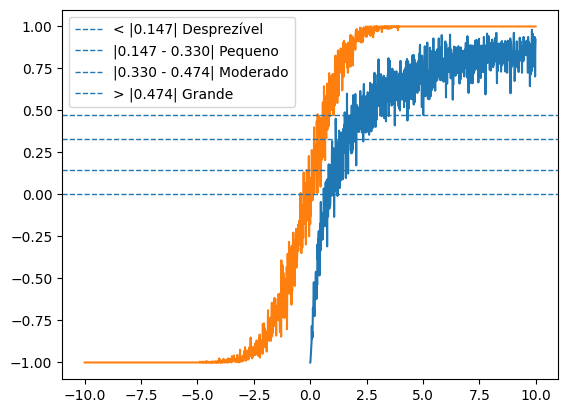

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

np.random.seed(42)

A = np.random.exponential(1,30)
cliffs_delta_array_exp = []
for b in np.arange(0,10,0.01):
  B = np.random.exponential(b,30)
  cliffs_delta_array_exp.append(cliffs_delta(B,A))

plt.plot(np.arange(0,10,0.01),cliffs_delta_array_exp)

A = norm.rvs(size=30)
cliffs_delta_array_norm = []
for b in np.arange(-10,10,0.01):
  B = norm.rvs(loc=b,size=30)
  cliffs_delta_array_norm.append(cliffs_delta(B,A))

plt.plot(np.arange(-10,10,0.01),cliffs_delta_array_norm)
plt.legend(['Exponencial','Normal'])

plt.axhline(0.0,label='< |0.147| Desprezível',linestyle='--',lw=1)
plt.axhline(0.147,label='|0.147 - 0.330| Pequeno',linestyle='--',lw=1)
plt.axhline(0.330,label='|0.330 - 0.474| Moderado',linestyle='--',lw=1)
plt.axhline(0.474,label='> |0.474| Grande',linestyle='--',lw=1)
plt.legend()
plt.show()



### Comparação de Distribuições

A Divergência de Jensen-Shannon (JSD) é uma métrica estatística não paramétrica usada para medir a semelhança ou diferença entre duas distribuições de probabilidade. Ela não um teste paramétrico, mas é útil pois compara de forma geral duas distribuições sob todos aspectos (diferença de média e variância,
multimodalidade, assimetria, formato). Por isso, estamos incluindo ela aqui. É como uma métrica de *tamanho do efeito* para distribuições.

* $ JSD \approx 0$ Distribuições quase idênticas
* $ JSD \approx 1$ Distribuições muito diferentes



In [ ]:
import numpy as np
from scipy.spatial.distance import jensenshannon

P = np.array([0.1,0.4,0.5])
Q = np.array([0.8,0.1,0.1])

jsd = jensenshannon(P,Q)

print(jsd)

0.5252654270805786


In [ ]:
P = np.random.normal(size=100,scale=4)
Q = np.random.normal(size=100)

jsd = jensenshannon(P,Q)

print(jsd)

inf


### Sumário dos Testes não Paramétricos

| Objetivo       | Função                                                |
| -------------- | ----------------------------------------------------- |
| Mann-Whitney   | `scipy.stats.mannwhitneyu`                            |
| Wilcoxon       | `scipy.stats.wilcoxon`                                |
| Kruskal-Wallis | `scipy.stats.kruskal`                                 |
| Friedman       | `scipy.stats.friedmanchisquare`                       |
| Permutation    | implementação manual / `scipy.stats.permutation_test` |
| Bootstrap      | 	implementação manual / `scipy.stats.bootstrap`                               |


## Testes de Correlação e Associação

Esses testes envolvem a associação, dependência e eventualmente a causalidade entre as variáveis. Como nos casos anteriores a inspeção visual pode ser útil e é necessária, veja o **Anscombe's quartet** (gráficos de dispersão, heatmaps, pair plots são aqui normalmente empregados).

Associação $\ne$ Causalidade: pense na venda de sorvetes $\times$ afogamentos na praia... Ohhh.

<br>

| Tipo           | Exemplo    |
| -------------- | ---------- |
| linear         | Pearson    |
| monotônica     | Spearman   |
| ordinal        | Kendall    |
| categórica     | Chi-square |





### Pearson Correlation

$$-1 \le r \le 1$$

Mede unicamente unicamente linearidade.

* $H_0$: São linearmente associadas
* $H_1$: Não são linearmente associadas

<br>
Note que $r(y=x^2,x^2) = 0$, mas com forte dependência.

<br>

> Acesse: https://www.tylervigen.com/spurious-correlations

> *Onde está a linearidade de $r \approx 1$.*

In [ ]:
import numpy as np
from scipy.stats import pearsonr

x = np.linspace(-5,5,100)
y = x**2

r, p = pearsonr(x,y)

print(r,p)

y = 2*x + np.random.normal(0,1,100)

r, p = pearsonr(x,y)

print(r,p)

-2.0816681711721685e-17 1.0
0.9865690485695605 6.241434425248759e-79


#### $R^2$

O coeficiente de determinação $R^2 = r^2$, é uma medida de efeito da correlação.

### Spearman Rank Correlation

É uma correlação baseada em ranks, substitui valores por ranks e mede associação monotônica.

* $H_0:$ São associadas monotonicamente
* $H_0:$ Não estão associadas monotonicamente

Monotonicamente associadas: Se o valor de uma variável aumenta (diminui), o valor da outra também aumenta (diminui) ou permanece o mesmo. O sentido da mudança é sempre preservado.


**Exemplo** Imagine a associação entre a satisfação de usuários e o tempo de resposta percebido.

In [ ]:
import numpy as np
from scipy.stats import spearmanr

np.random.seed(42)

x = np.random.exponential(size=100)
y = x + np.random.normal(0,0.5,100)

rho, p = spearmanr(x,y)

print(rho,p)

0.7434023402340234 8.173576832024435e-19


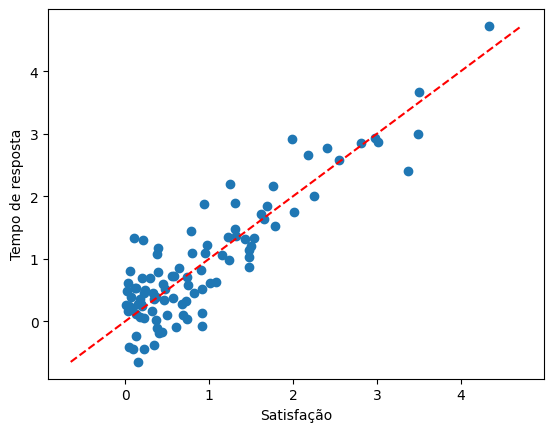

In [ ]:
plt.plot(x,y,'o')
plt.xlabel('Satisfação')
plt.ylabel('Tempo de resposta')
min_val = min(np.min(x), np.min(y))
max_val = max(np.max(x), np.max(y))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Linha Diagonal')

plt.show()

### Kendall Rank Correlation

Mede concordância ordinal (conta pares concordantes e discordantes). É útil para pequenas amostras, dados ordinais e escalas Likert.

$$\tau = \frac{C - D}{C+D}$$

Onde, $C$ são pares concordantes e $D$ discordantes.

* $H_0:$ não há correlação entre os dois rankings
* $H_0:$ há uma correlação significativa, positiva ou negativa


+1 (Alta Concordância), -1 (Alta Discordância)

**Exemplo** Ranking (1o 2o etc.) de funcionalidades de um App (Pagto por Pix, Modo Escuro, Relatórios etc.) entre 2 especialistas (diretor de Vendas e de Produto).

In [ ]:
import numpy as np
from scipy.stats import kendalltau

x = [1,2,3,4,5]
y = [1,2,2,4,5]

tau, p = kendalltau(x,y)

print(tau,p)

0.9486832980505137 0.022977401503206065


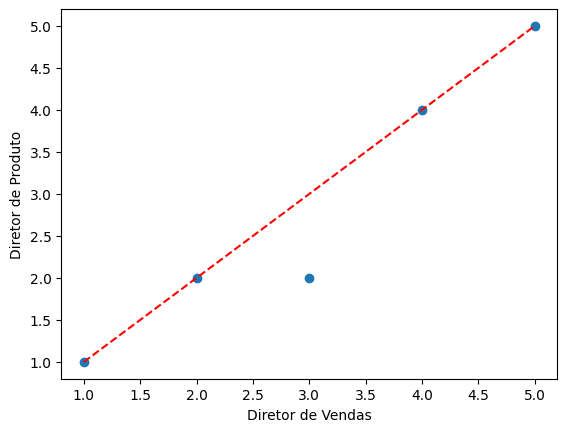

In [ ]:
plt.plot(x,y,'o')
plt.xlabel('Diretor de Vendas')
plt.ylabel('Diretor de Produto')
min_val = min(np.min(x), np.min(y))
max_val = max(np.max(x), np.max(y))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Linha Diagonal')

plt.show()

### Teste de Dependência $\chi^2$

É um teste de hipótese estatística examina se duas variáveis categóricas são independentes.

* $H_0$: São independentes
* $H_1$: São dependentes

**Exemplo** Relação entre vacina e internações.

In [ ]:
import numpy as np
import pandas as pd

np.random.seed(42)

N = 100

vacinados_count_1 = int(N * (.6))
vacinados_count_0 = N - vacinados_count_1
vacinados = np.array([1]*vacinados_count_1 + [0]*vacinados_count_0)
np.random.shuffle(vacinados)
vacinados

internados = vacinados.copy()
for i in range(len(internados)):
  if np.random.rand() > 0.3:
    if vacinados[i] == 1:
      internados[i] = 0
    else:
      internados[i] = 1
  else:
    internados[i] = vacinados[i]

contingency_table = pd.crosstab(pd.Series(vacinados, name='Vacinados'), pd.Series(internados, name='Internados'))
display(contingency_table)

Internados,0,1
Vacinados,,
0,13,27
1,42,18


In [ ]:
import numpy as np
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(contingency_table)

print(chi2,p)

12.163299663299663 0.0004873907632196624


**Rejeitamos a hipótese nula e os dados são dependentes**.

Nota: o expected, seriam os valores estimados para a hipótese nula (dados independentes).

In [ ]:
tab = pd.crosstab(pd.Series(vacinados, name='Vacinados'),
            pd.Series(internados, name='Internados'),
            margins=True,
            normalize=True)
tab.style.background_gradient(cmap='Blues')

Internados,0,1,All
Vacinados,,,
0,0.130000,0.270000,0.400000
1,0.420000,0.180000,0.600000
All,0.550000,0.450000,1.000000


P(não internado|vacinado) > P(não internado|não vacinado)?  

In [ ]:
tab = pd.crosstab(pd.Series(vacinados, name='Vacinados'),
            pd.Series(internados, name='Internados'))
tab.iloc[0,:] = expected[0,:]
tab.iloc[1,:] = expected[1,:]
tab.style.background_gradient(cmap='Blues')

Internados,0,1
Vacinados,,
0,22,18
1,33,27


#### $\chi^2$ Goodness-of-Fit

Um erro comum... não empregaremos aqui, mas o Chi-Square Goodness-of-Fit é um teste que compara aderência a uma distribuição/modelo.

**Exemplo** Pense da frenquência obtida e esperada dos valores de um dado lançado.

In [ ]:
import numpy as np
from scipy.stats import chisquare

observed = np.array([8,9,10,11,12,10])
expected = np.array([10,10,10,10,10,10])

chi2, p = chisquare(
    observed,
    f_exp=expected
)

print(chi2,p)

1.0 0.9625657732472964


#### Cramér’s V

O tamanho do efeito para associações categóricas.

In [ ]:
import numpy as np
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(contingency_table)

n = np.sum(np.array(contingency_table))
k = min(np.array(contingency_table).shape)

V = np.sqrt(chi2/(n*(k-1)))

print(V)

0.03232411914250689


### Informação Mútua

A informação mútua é uma medida extremamente geral de dependência estatística, aplicável a variáveis discretas e contínuas e que consegue detectar dependências arbitrárias, incluindo relações não lineares. Tem um papel importante no Aprendizado de Máquina, por exemplo na seleção de features.

$$ \sum_{x,y} p(x,y) \log \frac{p(x,y)}{p(x)p(y)} $$

> **Não vamos empregar neste semestre.**


In [ ]:
from sklearn.metrics import mutual_info_score

x = [0,0,1,1,1]
y = [0,1,1,1,0]

# y = [1,1,0,0,0]
# y = [0,0,1,1,1]

mi = mutual_info_score(x,y)

print(mi)

0.013844293808390418


In [ ]:
import numpy as np
from sklearn.feature_selection import mutual_info_regression

np.random.seed(42)

x = np.random.uniform(-2,2,1000)
y = x**2 + 0.1*np.random.normal(size=1000)

# y = 0.1*np.random.normal(size=1000)

mi = mutual_info_regression(
    x.reshape(-1,1),
    y
)

print(mi)

[2.20658333]


### Sumário de Correlação e Associação

| Objetivo           | Função                                 |
| ------------------ | -------------------------------------- |
| Pearson            | `scipy.stats.pearsonr`                 |
| Spearman           | `scipy.stats.spearmanr`                |
| Kendall            | `scipy.stats.kendalltau`               |
| Chi-square         | `scipy.stats.chi2_contingency`         |
| Mutual Information | `sklearn.metrics.mutual_info_score`    |


### **Discussão: Não relacionamos nenhum teste para de 'associação' de variáveis categóricas com numéricas.**

| Tipo variável X | Tipo variável Y | Técnicas típicas       |
| --------------- | --------------- | ---------------------- |
| numérica        | numérica        | Pearson, Spearman      |
| categórica      | categórica      | Chi-square, Cramér’s V |
| categórica      | numérica        | t-test, ANOVA          |
| numérica        | categórica      | regressão logística    |
